This script follows the capstone stage two black box optimisation challenge, this is the first attempt for week 1

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import os 
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import sys
from aima3 import learning
%matplotlib inline

import numpy as np
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as func
import sklearn 

In [149]:
# UCB function 
def acquisition_UCB(beta, mean, stddev, candidates):

    ucb = mean + beta * stddev # compute UCB 
    best_index = np.argmax(ucb) # find the argument x of a(x) that maximises 

    # use index to find best candidate function

    

    return np.round(candidates[best_index],6)

def accquisition_expected_improvement(mu, sigma, f_best, xi=0.0):
    """
    Compute Expected Improvement.

    Parameters
    ----------
    mu : array
        Posterior mean
    sigma : array
        Posterior std
    f_best : float
        Best observed value so far
    xi : float
        Exploration parameter (small positive value)

    Returns
    -------
    EI : array
    """

    sigma = np.maximum(sigma, 1e-12)  # avoid division by zero

    improvement = mu - f_best - xi
    Z = improvement / sigma

    EI = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    EI[sigma < 1e-12] = 0.0

    return EI


def accquisition_prob_improve(mu, sigma, f_best, xi=0.01):
    """
    Probability of Improvement (PI) acquisition function.

    Parameters
    ----------
    mu : array-like
        Posterior mean from GP
    sigma : array-like
        Posterior standard deviation from GP
    f_best : float
        Best observed value so far
    xi : float
        Exploration parameter (encourages exploration)

    Returns
    -------
    PI : array
        Probability of improvement at each point
    """

    mu = np.asarray(mu)
    sigma = np.asarray(sigma)

    # avoid division by zero
    sigma = np.maximum(sigma, 1e-12)

    Z = (mu - f_best - xi) / sigma

    PI = norm.cdf(Z)

    # if sigma ~ 0 → no uncertainty → no improvement possible
    PI[sigma < 1e-12] = 0.0

    return PI


# implement GPR with a RBF kernel 
def GPR_with_RBF_kernel_monte_carlo(rbf_lengthscale,
                        noise_assumption,
                        ins,outs,
                        sample_size,
                        in_cols):
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed') # user defined length scale 
    #kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-3, 1e3)) # letting GP learn the length scale of the data
    model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

    # normalise all dimensions 
    
   
    #fit data to GPR model 
    model.fit(ins,outs)



    # generate possible coordinate samples for acquisition function

    rng = np.random.default_rng(seed=42)

    sample_ins = rng.random((sample_size, in_cols))
    #print(sample_ins.shape)

    # above sample assumes the coords are between [0,1)

    post_mean, post_std = model.predict(sample_ins ,return_std=True)

    return post_mean, post_std, sample_ins

def GPR_with_RBF_kernel_grid_search(rbf_lengthscale,
                        noise_assumption,
                        ins,outs,
                        n_points,
                        ):
    
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed') # user defined length scale 
    #kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds=(1e-3, 1e3)) # letting GP learn the length scale of the data
    model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)

    # normalise all dimensions 
    
   
    #fit data to GPR model 
    model.fit(ins,outs)



    # generate possible coordinate samples for acquisition function

    x1 = np.linspace(0,1,n_points)
    x2 = np.linspace(0,1,n_points)

    X1, X2 = np.meshgrid(x1, x2)

    sample_ins = np.vstack([X1.ravel(), X2.ravel()]).T
    #print(sample_ins.shape)

    # above sample assumes the coords are between [0,1)

    post_mean, post_std = model.predict(sample_ins ,return_std=True)

    return post_mean, post_std, sample_ins


def GPR_with_learned_hyperparameters(
    ins,
    outs,
    sample_size,
    in_cols,
    initial_length_scale=0.5,
    initial_noise=1e-4,
    n_restarts=10
):
    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * RBF(length_scale=initial_length_scale, length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=initial_noise, noise_level_bounds=(1e-8, 1e0))
    )

    model = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=n_restarts,
        normalize_y=True,
        random_state=42
    )

    model.fit(ins, outs)

    rng = np.random.default_rng(seed=42)
    sample_ins = rng.random((sample_size, in_cols))

    post_mean, post_std = model.predict(sample_ins, return_std=True)

    return post_mean, post_std, sample_ins, model

def propose_points_from_learned_gp(ins, outs, sample_size, in_cols, Beta, Xi):
    post_mean, post_std, sample_ins, model = GPR_with_learned_hyperparameters(
        ins=ins,
        outs=outs,
        sample_size=sample_size,
        in_cols=in_cols,
        initial_length_scale=0.5,
        initial_noise=1e-4,
        n_restarts=10
    )

    f_best = np.max(outs)

    x_next_UCB = acquisition_UCB(Beta, post_mean, post_std, sample_ins)

    ei = accquisition_expected_improvement(post_mean, post_std, f_best)
    x_next_EI = sample_ins[np.argmax(ei)]

    pi = accquisition_prob_improve(post_mean, post_std, f_best, xi=Xi)
    x_next_PI = sample_ins[np.argmax(pi)]

    return {
        "UCB": np.round(x_next_UCB, 6),
        "EI": np.round(x_next_EI, 6),
        "PI": np.round(x_next_PI, 6),
        "model": model
    }


def check_unit_cube(X, tol=1e-12):
    """
    Per-dimension check of whether inputs lie in [0,1].
    """

    X = np.asarray(X)

    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)

    for i, (mn, mx) in enumerate(zip(mins, maxs)):
        status = (mn >= -tol) and (mx <= 1 + tol)

        print(f"Dim {i}: min={mn:.6f}, max={mx:.6f} -> "
              f"{'OK' if status else 'OUT OF RANGE'}")

    return np.all((mins >= -tol) & (maxs <= 1 + tol))

def compute_acquisition_consistency(results):
    """
    Compute consistency (max pairwise distance) for each noise level.

    Parameters
    ----------
    results : list of dict
        Each dict contains:
        {'noise': ..., 'UCB': ..., 'EI': ..., 'PI': ...}

    Returns
    -------
    summary : list of dict
        [{'noise': ..., 'consistency': ...}, ...]
    """

    summary = []

    for entry in results:
        x_ucb = np.asarray(entry['UCB'])
        x_ei  = np.asarray(entry['EI'])
        x_pi  = np.asarray(entry['PI'])

        # pairwise distances
        d_ue = np.linalg.norm(x_ucb - x_ei)
        d_up = np.linalg.norm(x_ucb - x_pi)
        d_ep = np.linalg.norm(x_ei - x_pi)

        d_max = max(d_ue, d_up, d_ep)

        summary.append({
            'noise': entry['noise'],
            'consistency': d_max
        })

    return summary

def compute_between_noise_distances(results, key):
    distances = []

    for i in range(len(results) - 1):
        x1 = np.asarray(results[i][key], dtype=float)
        x2 = np.asarray(results[i + 1][key], dtype=float)

        dist = np.linalg.norm(x2 - x1)
        distances.append(dist)

    return np.array(distances)  # ← FIX HERE

def select_noise_from_stability(results, key='UCB', tol=1e-6):
    """
    Select a noise level based on stability of the predicted next point.

    Strategy
    --------
    1. Compute distances between predicted points at consecutive noise levels.
    2. Mark transitions where the prediction does NOT change (distance < tol).
    3. Identify the longest consecutive region of stability.
    4. Choose the midpoint of this region as a representative noise level.

    Parameters
    ----------
    results : list of dict
        Each entry has the form:
        {'noise': ..., 'UCB': ..., 'EI': ..., 'PI': ...}

    key : str
        Which acquisition function to use ('UCB', 'EI', or 'PI').

    tol : float
        Tolerance for deciding if two points are "the same".
        If distance < tol → considered stable.

    Returns
    -------
    dict
        {
            'noise': selected noise value,
            'x_next': predicted next point at that noise,
            'index': index of selected noise in results
        }
    """

    # Step 1: compute distances between consecutive noise levels
    # distances[i] = || x(sigma_{i+1}) - x(sigma_i) ||
    distances = compute_between_noise_distances(results, key)

    # Step 2: convert distances into a boolean stability mask
    # True  → no change in predicted point (stable)
    # False → change occurred (instability / jump)
    stable = distances < tol

    # Step 3: find the longest consecutive "True" segment
    max_len = 0        # length of longest stable segment found so far
    best_start = 0     # starting index of that segment

    current_len = 0    # length of current segment being tracked
    current_start = 0  # start index of current segment

    for i, val in enumerate(stable):

        if val:
            # If entering a new stable segment, record where it starts
            if current_len == 0:
                current_start = i

            # Extend current stable segment
            current_len += 1

            # Update best segment if this one is longer
            if current_len > max_len:
                max_len = current_len
                best_start = current_start

        else:
            # Instability encountered → reset current segment
            current_len = 0

    # Step 4: choose midpoint of the longest stable segment
    # This avoids picking boundary values and gives a representative point
    best_index = best_start + max_len // 2

    # Step 5: return the corresponding noise and predicted next point
    return {
        'noise': results[best_index]['noise'],
        'x_next': results[best_index][key],
        'index': best_index
    }

def get_best_observed_input(ins, outs):
    idx = np.argmax(outs)
    return ins[idx]

def select_best_acquisition_from_candidates(x_ucb, x_ei, x_pi, best_input):
    """
    Select the acquisition function whose predicted point
    is closest to the previously observed best input.
    """

    best_input = np.asarray(best_input, dtype=float)

    d_ucb = np.linalg.norm(np.asarray(x_ucb) - best_input)
    d_ei  = np.linalg.norm(np.asarray(x_ei)  - best_input)
    d_pi  = np.linalg.norm(np.asarray(x_pi)  - best_input)

    distances = {
        "UCB": d_ucb,
        "EI": d_ei,
        "PI": d_pi
    }

    best_key = min(distances, key=distances.get)

    return {
        "selected_acquisition": best_key,
        "selected_point": {
            "UCB": x_ucb,
            "EI": x_ei,
            "PI": x_pi
        }[best_key],
        "distances": distances

    
    }

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def conduct_PCA(
    observed_inputs,
    special_points=None,
    standardise=True,
    n_components=2
):
    """
    Perform PCA on the observed input space and project both the observed
    points and any additional special points into the same PCA space.

    Parameters
    ----------
    observed_inputs : array-like of shape (n_samples, n_features)
        The input points already observed by the optimisation procedure.

    special_points : dict or None, default=None
        Optional dictionary of named points to project using the same PCA map.
        Example:
            {
                "UCB": x_ucb,
                "EI": x_ei,
                "PI": x_pi
            }
        Each value should be a 1D array of shape (n_features,).

    standardise : bool, default=True
        If True, standardise each input dimension before PCA.
        This is usually a good idea unless all features are already on
        exactly comparable scales.

    n_components : int, default=2
        Number of principal components to retain.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "observed_projected": PCA coordinates of observed_inputs
        - "special_projected": dict of projected special points
        - "explained_variance_ratio": variance explained by each component
        - "pca_model": fitted PCA object
        - "scaler": fitted scaler or None
    """
    X_obs = np.asarray(observed_inputs)

    if X_obs.ndim != 2:
        raise ValueError("observed_inputs must be a 2D array of shape (n_samples, n_features)")

    if special_points is None:
        special_points = {}

    # Stack all points so scaling/PCA are fitted consistently
    all_points = [X_obs]
    special_names = []
    special_arrays = []

    for name, point in special_points.items():
        point = np.asarray(point)
        if point.ndim != 1:
            raise ValueError(f"Special point '{name}' must be a 1D array of shape (n_features,)")
        if point.shape[0] != X_obs.shape[1]:
            raise ValueError(
                f"Special point '{name}' has {point.shape[0]} features, "
                f"but observed_inputs has {X_obs.shape[1]}"
            )
        special_names.append(name)
        special_arrays.append(point.reshape(1, -1))
        all_points.append(point.reshape(1, -1))

    X_all = np.vstack(all_points)

    scaler = None
    if standardise:
        scaler = StandardScaler()
        X_all_scaled = scaler.fit_transform(X_all)
    else:
        X_all_scaled = X_all.copy()

    pca_model = PCA(n_components=n_components)
    X_all_projected = pca_model.fit_transform(X_all_scaled)

    n_obs = X_obs.shape[0]
    observed_projected = X_all_projected[:n_obs]

    special_projected = {}
    idx = n_obs
    for name in special_names:
        special_projected[name] = X_all_projected[idx]
        idx += 1

    results = {
        "observed_projected": observed_projected,
        "special_projected": special_projected,
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "pca_model": pca_model,
        "scaler": scaler
    }

    return results

def plot_PCA_projection(
    pca_results,
    observed_outputs=None,
    title="PCA projection of input space"
):
    """
    Plot the 2D PCA projection of observed inputs and optional special points.

    Parameters
    ----------
    pca_results : dict
        Output from conduct_PCA().

    observed_outputs : array-like or None, default=None
        Optional values used to colour the observed points.

    title : str, default="PCA projection of input space"
        Plot title.
    """
    observed_projected = pca_results["observed_projected"]
    special_projected = pca_results["special_projected"]
    evr = pca_results["explained_variance_ratio"]

    plt.figure(figsize=(8, 6))

    if observed_outputs is None:
        plt.scatter(
            observed_projected[:, 0],
            observed_projected[:, 1],
            alpha=0.7,
            label="Observed inputs"
        )
    else:
        observed_outputs = np.asarray(observed_outputs).ravel()
        scatter = plt.scatter(
            observed_projected[:, 0],
            observed_projected[:, 1],
            c=observed_outputs,
            alpha=0.8
        )
        plt.colorbar(scatter, label="Observed output")

    for name, point in special_projected.items():
        plt.scatter(point[0], point[1], s=120, marker="X", label=name)
        plt.text(point[0], point[1], f" {name}", fontsize=10, va="center")

    plt.xlabel(f"PC1 ({100 * evr[0]:.1f}% variance)")
    plt.ylabel(f"PC2 ({100 * evr[1]:.1f}% variance)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def conduct_tSNE(
    observed_inputs,
    special_points=None,
    standardise=True,
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    max_iter=1000,
    random_state=42
):
    """
    Perform t-SNE on the observed input space, optionally including special
    points such as UCB/EI/PI proposals in the same embedding.

    Parameters
    ----------
    observed_inputs : array-like of shape (n_samples, n_features)
        Observed input points.

    special_points : dict or None, default=None
        Optional dictionary of named 1D points to include in the embedding.
        Example:
            {
                "UCB": x_ucb,
                "EI": x_ei,
                "PI": x_pi
            }

    standardise : bool, default=True
        Whether to standardise the features before t-SNE.

    n_components : int, default=2
        Number of embedding dimensions.

    perplexity : float, default=30
        t-SNE perplexity parameter. Must be smaller than the total number
        of points in the combined dataset.

    learning_rate : float or "auto", default="auto"
        t-SNE learning rate.

    max_iter : int, default=1000
        Number of optimisation iterations.

    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    results : dict
        Dictionary containing:
        - "observed_embedded": embedded coordinates of observed_inputs
        - "special_embedded": dict of embedded special points
        - "tsne_model": fitted TSNE instance
    """
    X_obs = np.asarray(observed_inputs)

    if X_obs.ndim != 2:
        raise ValueError("observed_inputs must be a 2D array of shape (n_samples, n_features)")

    if special_points is None:
        special_points = {}

    all_points = [X_obs]
    special_names = []

    for name, point in special_points.items():
        point = np.asarray(point)
        if point.ndim != 1:
            raise ValueError(f"Special point '{name}' must be a 1D array")
        if point.shape[0] != X_obs.shape[1]:
            raise ValueError(
                f"Special point '{name}' has {point.shape[0]} features, "
                f"but observed_inputs has {X_obs.shape[1]}"
            )
        all_points.append(point.reshape(1, -1))
        special_names.append(name)

    X_all = np.vstack(all_points)

    if perplexity >= X_all.shape[0]:
        raise ValueError(
            f"perplexity={perplexity} must be smaller than the total number "
            f"of points={X_all.shape[0]}"
        )

    if standardise:
        scaler = StandardScaler()
        X_all = scaler.fit_transform(X_all)

    tsne_model = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        learning_rate=learning_rate,
        max_iter=max_iter,
        init="pca",
        random_state=random_state
    )

    X_all_embedded = tsne_model.fit_transform(X_all)

    n_obs = X_obs.shape[0]
    observed_embedded = X_all_embedded[:n_obs]

    special_embedded = {}
    idx = n_obs
    for name in special_names:
        special_embedded[name] = X_all_embedded[idx]
        idx += 1

    results = {
        "observed_embedded": observed_embedded,
        "special_embedded": special_embedded,
        "tsne_model": tsne_model
    }

    return results   

def plot_tSNE_projection(
        
    tsne_results,
    observed_outputs=None,
    title="t-SNE projection of input space"
):
    """
    Plot the 2D t-SNE embedding of observed inputs and optional special points.

    Parameters
    ----------
    tsne_results : dict
        Output from conduct_tSNE().

    observed_outputs : array-like or None, default=None
        Optional values used to colour observed points.

    title : str, default="t-SNE projection of input space"
        Plot title.
    """
    observed_embedded = tsne_results["observed_embedded"]
    special_embedded = tsne_results["special_embedded"]

    plt.figure(figsize=(8, 6))

    if observed_outputs is None:
        plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            alpha=0.7,
            label="Observed inputs"
        )
    else:
        observed_outputs = np.asarray(observed_outputs).ravel()
        scatter = plt.scatter(
            observed_embedded[:, 0],
            observed_embedded[:, 1],
            c=observed_outputs,
            alpha=0.8
        )
        plt.colorbar(scatter, label="Observed output")

    for name, point in special_embedded.items():
        plt.scatter(point[0], point[1], s=140, marker="X", label=name)
        plt.text(point[0], point[1], f" {name}", fontsize=10, va="center")

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def monte_carlo_sample_from_neural_net(sample_size,in_cols,model):
        rng = np.random.default_rng(seed=42)

        sample_ins = rng.random((sample_size, in_cols))

        sample_ins_torch= torch.tensor(sample_ins,dtype=torch.float32)
        post_mean = model(sample_ins_torch)
        
        return  post_mean,sample_ins


def simple_neural_network(ins,outs,sample_size, learn_rate):
        # 1 hidden layer 

        print(ins.shape)
        in_cols=ins.shape[1]
        # create input tensor from ins of function 
        X = torch.tensor(ins,dtype=torch.float32)#Use numpy commands – example input to Layer 2
        y= torch.tensor(outs,dtype=torch.float32)

        model=nn.Sequential(
            nn.Linear(ins.shape[1],ins.shape[1]), # mapping 13x 2 inputs to 13x2 outputs 
            nn.ReLU(), # applying rectified linear unit activation function 
            nn.Linear(ins.shape[1],1) # mapping the 13x2 inputs to 13x1 outputs 
        )


        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=learn_rate) # stochastic gradient descent 

        num_epochs=20000

        for epoch in range(num_epochs):
            # Forward pass: predictions from current model parameters
            y_pred = model(X)

            # Compute loss
            loss = criterion(y_pred, y)

            # Clear old gradients
            optimizer.zero_grad()

            # Backward pass: compute gradients of loss wrt parameters
            loss.backward()

            # Gradient descent step
            optimizer.step()

            # Print progress occasionally
            # if epoch % 2000 == 0:
            #     print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

        print(f"Epoch {epoch}, final Loss = {loss.item():.6f}")


        
            

        post_mean,sample_ins=monte_carlo_sample_from_neural_net(sample_size,in_cols,model)
        # max post mean evaluation 
        max_post_mmean_idx=np.argmax(post_mean.detach().numpy())
        reccomended_point_from_neual_net=sample_ins[max_post_mmean_idx]
        #print("reccomended_point_from_neual_net",reccomended_point_from_neual_net)

        return reccomended_point_from_neual_net


def simple_neural_net_w_5_cross_fold_validation(ins,outs,sample_size,learn_rate):
    in_cols=ins.shape[1]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_val_losses=[]
    for train_idx, val_idx in kf.split(ins):
        X_train = torch.tensor(ins[train_idx], dtype=torch.float32)
        y_train = torch.tensor(outs[train_idx], dtype=torch.float32).view(-1, 1)

        X_val = torch.tensor(ins[val_idx], dtype=torch.float32)
        y_val = torch.tensor(outs[val_idx], dtype=torch.float32).view(-1, 1)


        model=nn.Sequential(
            nn.Linear(ins.shape[1],ins.shape[1]), # mapping 13x 2 inputs to 13x2 outputs 
            nn.ReLU(), # applying rectified linear unit activation function 
            nn.Linear(ins.shape[1],1) # mapping the 13x2 inputs to 13x1 outputs 
        )


        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=learn_rate) # stochastic gradient descent 

        num_epochs=10000

        for epoch in range(num_epochs):
            # Forward pass: predictions from current model parameters
            y_pred = model(X_train)

            # Compute loss
            loss = criterion(y_pred, y_train)

            # Clear old gradients
            optimizer.zero_grad()

            # Backward pass: compute gradients of loss wrt parameters
            loss.backward()

            # Gradient descent step
            optimizer.step()
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, y_val)

            # Print progress occasionally
            # if epoch % 2000 == 0:
            #     print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

            fold_val_losses.append(val_loss.item())



    mean_val_loss = np.mean(fold_val_losses)
    print("Mean CV loss:", mean_val_loss)

    post_mean,sample_ins=monte_carlo_sample_from_neural_net(sample_size,in_cols,model)
    # max post mean evaluation 
    max_post_mmean_idx=np.argmax(post_mean.detach().numpy())
    reccomended_point_from_neual_net=sample_ins[max_post_mmean_idx]
    print("reccomended_point_from_neual_net",reccomended_point_from_neual_net)

    return mean_val_loss ,reccomended_point_from_neual_net

Need to take the old data and the new inputs and outputs. Can join them together to get the new data set.


In [113]:
# simply paste new inputs below for the next week. 

new_outs=[np.float64(9.656222973626152e-41), 
          np.float64(0.6502465023339654), 
          np.float64(-0.02360529873688974), 
          np.float64(0.12440971394229594),
            np.float64(5079.038688784203),
              np.float64(-0.33100281642937823),
                np.float64(1.4621950122984007),
                  np.float64(9.9032406274175)]

for x in range(1,9):
    print("function output:", new_outs[x-1])



new_inputs=[np.array([0.773956, 0.438878]),
             np.array([0.709709, 0.891149]),
              np.array([0.38555 , 0.375524, 0.482404]),
                 np.array([0.438124, 0.445688, 0.429389, 0.411138]),
                   np.array([0.7066  , 0.999024, 0.993655, 0.986456]), 
                  np.array([0.495801, 0.399488, 0.429158, 0.771171, 0.19058 ]), 
                  np.array([0.061748, 0.437126, 0.232414, 0.145199, 0.362887, 0.770468]),
                   np.array([0.116894, 0.299157, 0.168593, 0.255988, 0.618273, 0.617996, 0.31299 , 0.44933 ])]




def join_new_data_to_old(new_outs,new_inputs,data_file,new_file_deposit_path):
    # need to join the new y output 
    for i in range(1,9):
        ins=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/{data_file}/function_{i}/inputs.npy")
        outs=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/{data_file}/function_{i}/outputs.npy")
        
        
        #add row index for concatenation of the new inputs 
        new_ins_concat=np.reshape(new_inputs[i-1],(1,new_inputs[i-1].shape[0])) 
        # make single output into array for concat 
        new_outs_concat=np.array([new_outs[i-1]])
        


        new_input_arr=np.concatenate((ins,new_ins_concat),axis=0)
        print(new_input_arr.shape)
        new_output_arr=np.concatenate((outs,new_outs_concat),axis=0)
        print(new_output_arr.shape)

        print(os.getcwd())
        
        os.mkdir(f'{new_file_deposit_path}/function_{i}')
        np.save( f'{new_file_deposit_path}/function_{i}/inputs.npy',new_input_arr)
        np.save( f'{new_file_deposit_path}/function_{i}/outputs.npy',new_output_arr)





data_file='week_3/week_3_data'  
new_file_deposit_path='week_4_data'
join_new_data_to_old(new_outs,new_inputs,data_file,new_file_deposit_path)



function output: 9.656222973626152e-41
function output: 0.6502465023339654
function output: -0.02360529873688974
function output: 0.12440971394229594
function output: 5079.038688784203
function output: -0.33100281642937823
function output: 1.4621950122984007
function output: 9.9032406274175
(13, 2)
(13,)
/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_4


FileExistsError: [Errno 17] File exists: 'week_4_data/function_1'

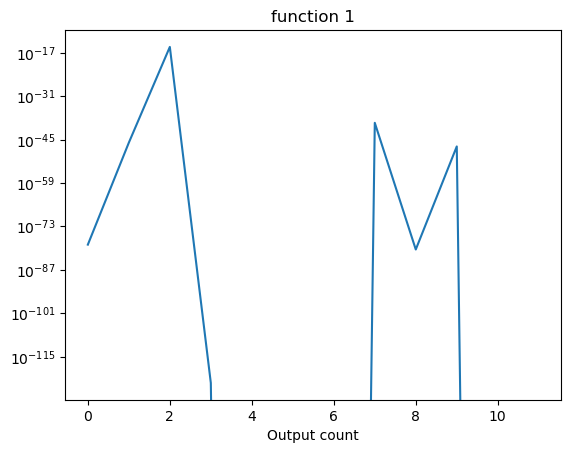

[[3.19403889e-01 7.62959374e-01]
 [5.74329215e-01 8.79898105e-01]
 [7.31023631e-01 7.32999876e-01]
 [8.40353417e-01 2.64731614e-01]
 [6.50114060e-01 6.81526352e-01]
 [4.10437137e-01 1.47554299e-01]
 [3.12691157e-01 7.87227779e-02]
 [6.83418169e-01 8.61057464e-01]
 [8.25072518e-02 4.03487506e-01]
 [8.83889829e-01 5.82253974e-01]
 [4.45000000e-03 9.94344000e-01]
 [9.99235000e-01 2.98000000e-04]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  0.00000000e+000  0.00000000e+000]


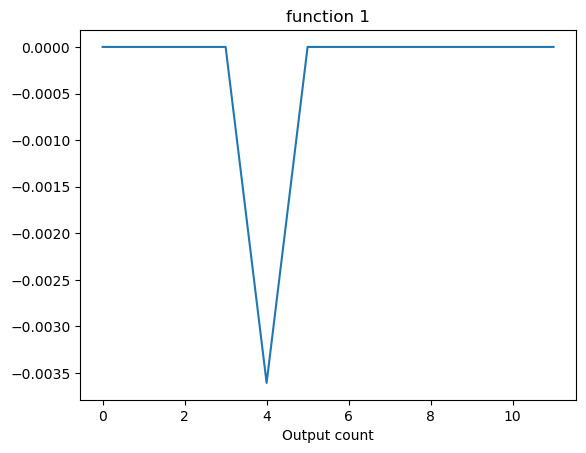

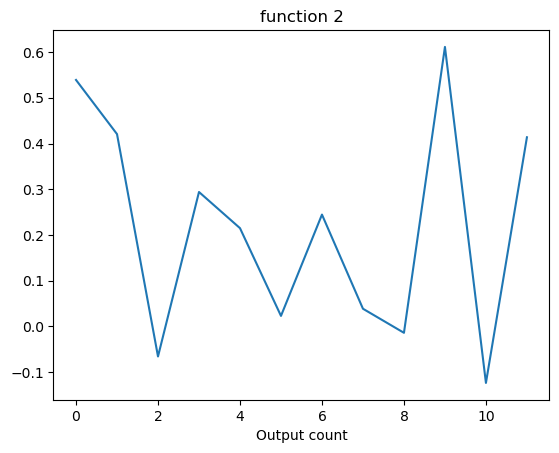

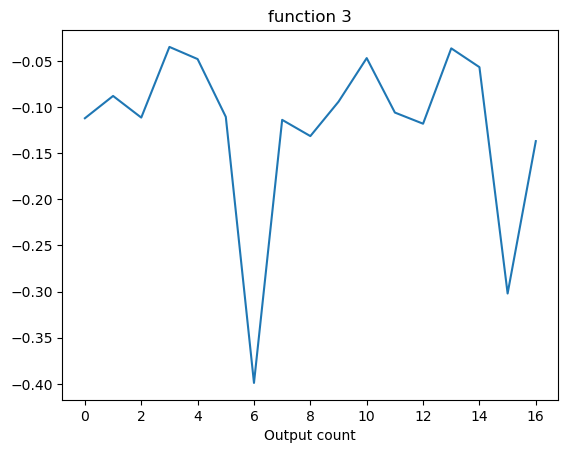

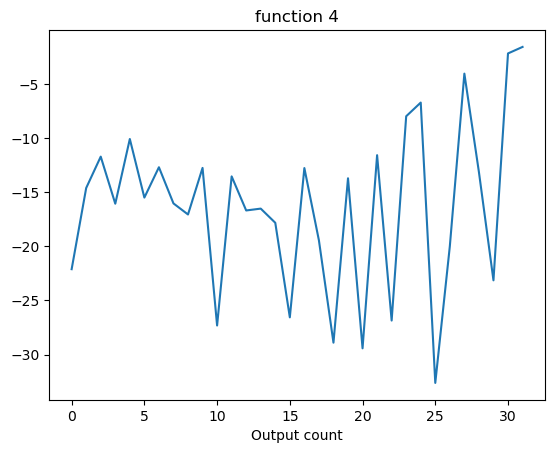

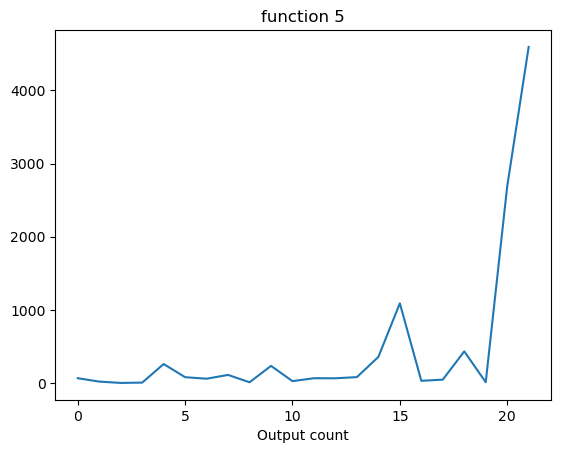

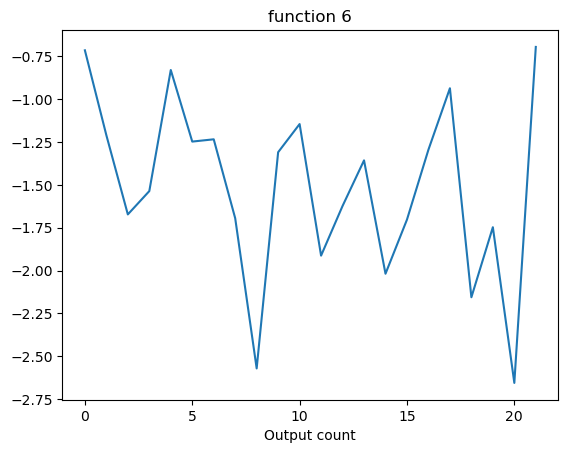

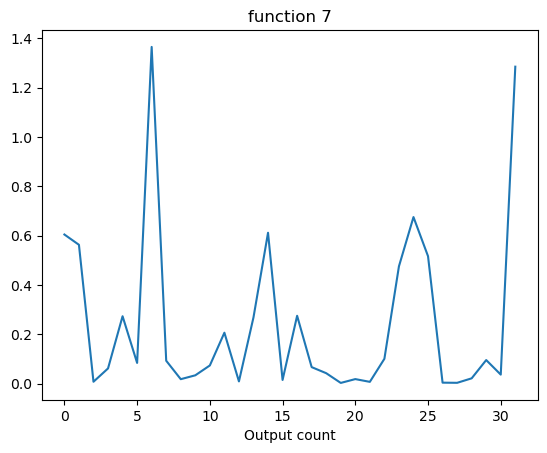

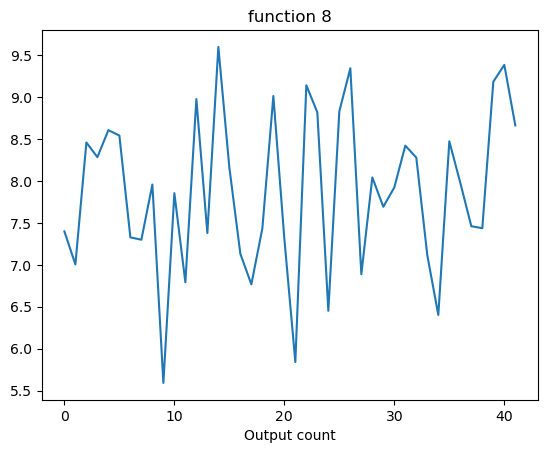

In [9]:
# visualise data so far
for k in range(1,9):
    ins=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_3/week_3_data/function_{k}/inputs.npy")
    #print(ins)
    outs=np.load(f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_3/week_3_data/function_{k}/outputs.npy")
    if k==1:
        plt.plot(outs)
        plt.title(f"function {k}")
        plt.xlabel("Output count")
        plt.yscale('log')
        plt.show()
        print(ins)
        print(outs)


    
    plt.plot(outs)
    plt.title(f"function {k}")
    plt.xlabel("Output count")
    plt.show()



## Gaussian process hyperparameter learning via log marginal likelihood

In this loop, we fit a Gaussian process (GP) surrogate model separately for each black-box function.  
Unlike the earlier approach, we do **not** manually sweep over assumed noise values. Instead, the GP learns its own hyperparameters directly from the observed data by maximising the **log marginal likelihood** during training.

### Kernel and learned hyperparameters

The GP uses a kernel of the form

$$
k(\mathbf{x},\mathbf{x}')
=
\sigma_f^2
\exp\!\left(
-\frac{\|\mathbf{x}-\mathbf{x}'\|^2}{2\ell^2}
\right)
+
\sigma_n^2 \delta_{\mathbf{x},\mathbf{x}'},
$$

where:

- \(\sigma_f^2\) is the signal variance,
- \(\ell\) is the RBF kernel length scale,
- \(\sigma_n^2\) is the observation noise variance.

These quantities are treated as unknown hyperparameters and are estimated automatically when the GP is fitted.

### Log marginal likelihood optimisation

Given observed inputs \(X\) and outputs \(\mathbf{y}\), the GP defines a covariance matrix \(K_\theta\) that depends on the hyperparameters \(\theta\).  
The hyperparameters are chosen by maximising the log marginal likelihood

$$
\log p(\mathbf{y}\mid X,\theta)
=
-\frac{1}{2}\mathbf{y}^\top K_\theta^{-1}\mathbf{y}
-\frac{1}{2}\log |K_\theta|
-\frac{n}{2}\log(2\pi).
$$

This balances three effects:

- **data fit**: the model should explain the observed outputs well,
- **complexity control**: overly flexible covariance structures are penalised through \(\log |K_\theta|\),
- **probabilistic consistency**: the full GP model must assign high probability to the data.

In practice, this optimisation is carried out internally by `GaussianProcessRegressor.fit(...)`.  
The parameter `n_restarts_optimizer=10` is used to reduce the chance of the optimiser stopping at a poor local optimum.

### Loop workflow

For each test function, the loop performs the following steps:

1. Load the current observed input-output pairs.
2. Fit a GP with optimisable kernel hyperparameters.
3. Learn the kernel length scale, signal variance, and noise level by maximising the log marginal likelihood.
4. Evaluate the GP posterior mean and posterior standard deviation on a large Monte Carlo candidate set.
5. Use three acquisition functions --- Upper Confidence Bound (UCB), Expected Improvement (EI), and Probability of Improvement (PI) --- to propose candidate next evaluation points.

### Difference from the earlier version

Previously, a separate outer loop manually varied the assumed noise level and then selected a stable candidate.  
That manual sweep has been removed. The GP now performs hyperparameter selection internally and automatically, giving a single learned probabilistic model for each function before the acquisition functions are evaluated.

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


function number 1
Learned kernel: 0.995**2 * RBF(length_scale=0.001) + WhiteKernel(noise_level=0.00932)
Optimised log marginal likelihood: -18.446200931660744
Mean CV loss: 0.0039803394890791655
reccomended_point_from_neual_net [7.99500842e-04 9.99830803e-01]
Next point UCB: [0.68388  0.859533]
Next point EI : [0.573842 0.878407]
Next point PI : [0.773956 0.438878]
Next point NN [7.99500842e-04 9.99830803e-01], mean validation loss 0.0039803394890791655
previous input point [0.773956 0.438878]


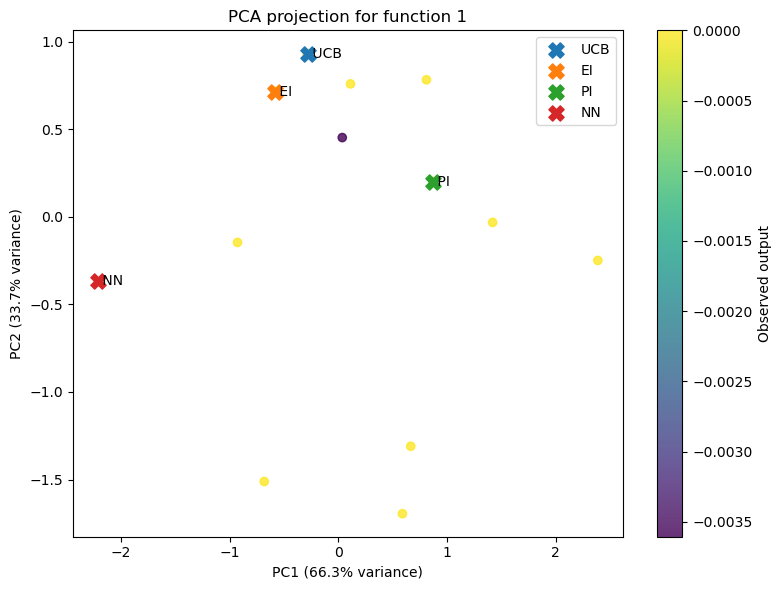

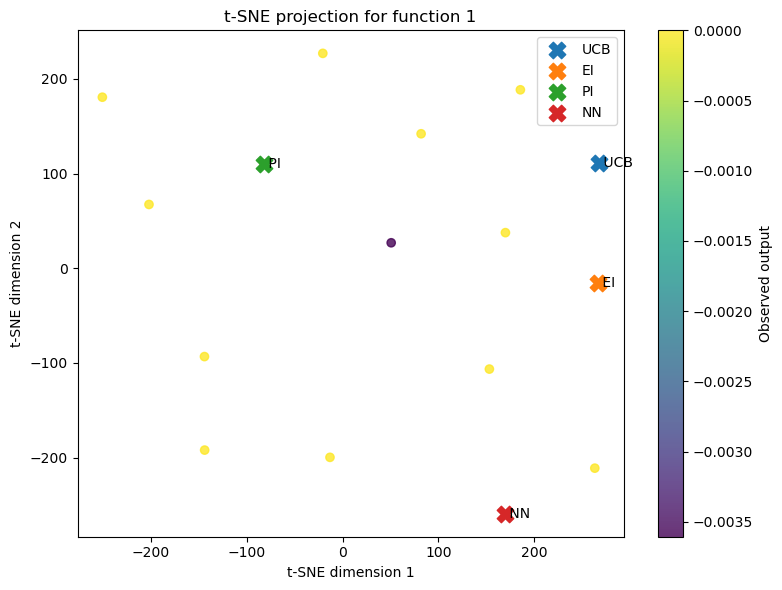

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


function number 2
Learned kernel: 0.945**2 * RBF(length_scale=0.0957) + WhiteKernel(noise_level=1e-08)
Optimised log marginal likelihood: -15.473673908230381
Mean CV loss: 0.07906558459856984
reccomended_point_from_neual_net [0.99997255 0.99984253]
Next point UCB: [0.675242 0.893912]
Next point EI : [0.772416 0.855168]
Next point PI : [0.674794 0.239267]
Next point NN [0.99997255 0.99984253], mean validation loss 0.07906558459856984
previous input point [0.709709 0.891149]


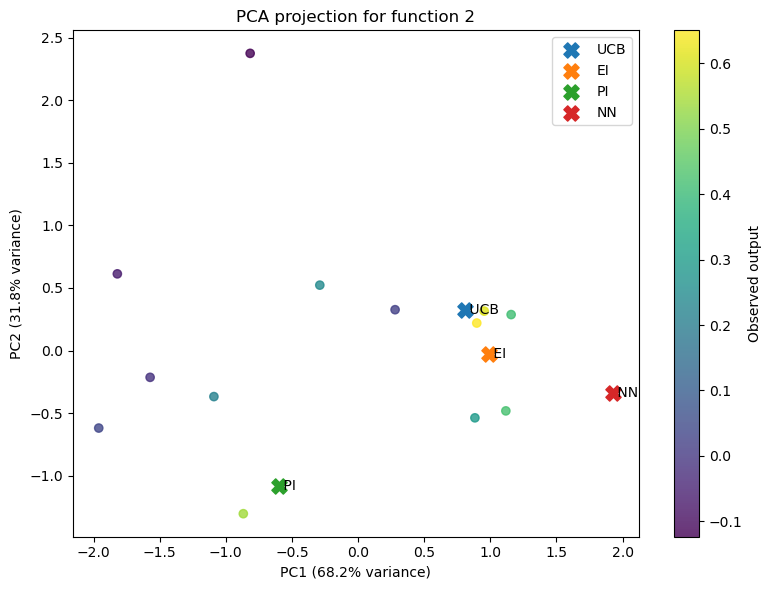

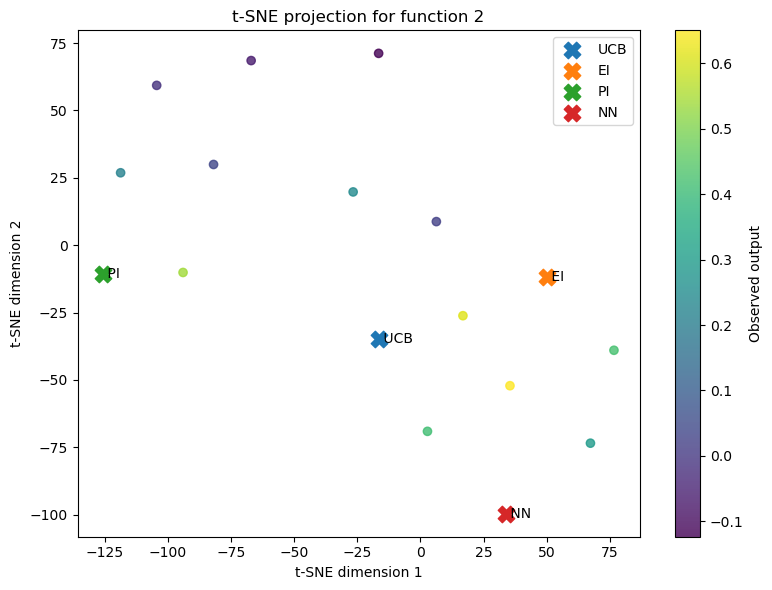

function number 3
Learned kernel: 1.08**2 * RBF(length_scale=0.227) + WhiteKernel(noise_level=0.0386)
Optimised log marginal likelihood: -23.505749678154583
Mean CV loss: 0.01777221801160951
reccomended_point_from_neual_net [4.71193416e-04 9.77146604e-01 9.94639337e-02]
Next point UCB: [0.349769 0.140773 0.478682]
Next point EI : [0.349769 0.140773 0.478682]
Next point PI : [0.410044 0.003597 0.475906]
Next point NN [4.71193416e-04 9.77146604e-01 9.94639337e-02], mean validation loss 0.01777221801160951
previous input point [0.38555  0.375524 0.482404]


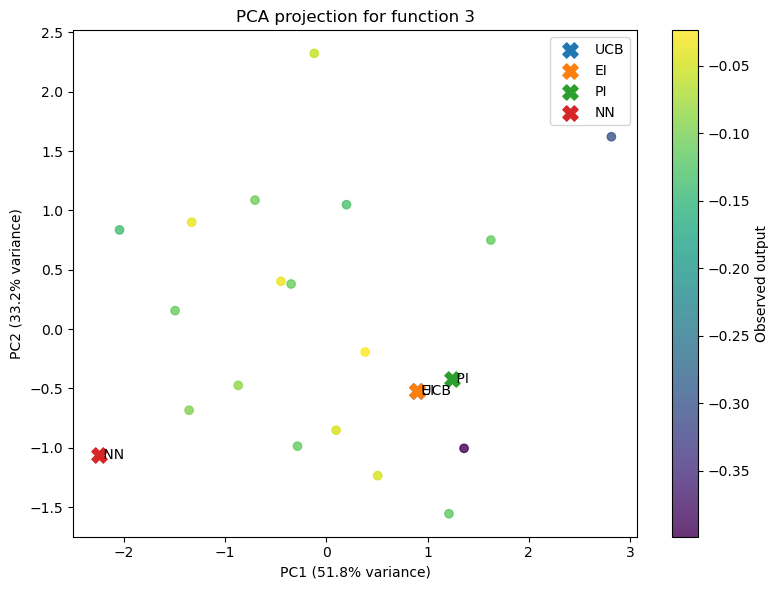

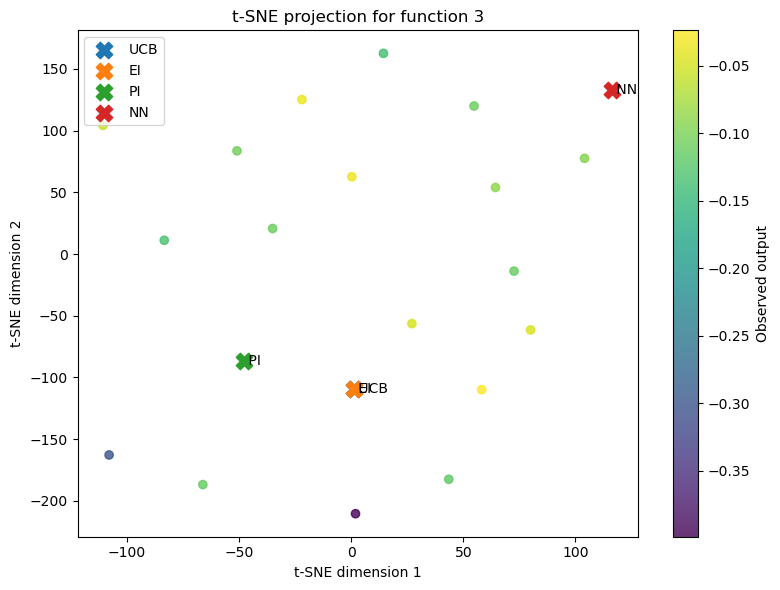

function number 4
Learned kernel: 1.84**2 * RBF(length_scale=0.718) + WhiteKernel(noise_level=0.00366)
Optimised log marginal likelihood: -16.412562924417088
Mean CV loss: 49.13607917022705
reccomended_point_from_neual_net [0.00357863 0.03020806 0.03567706 0.01598807]
Next point UCB: [0.389512 0.40935  0.38951  0.420182]
Next point EI : [0.389512 0.40935  0.38951  0.420182]
Next point PI : [0.389512 0.40935  0.38951  0.420182]
Next point NN [0.00357863 0.03020806 0.03567706 0.01598807], mean validation loss 49.13607917022705
previous input point [0.438124 0.445688 0.429389 0.411138]


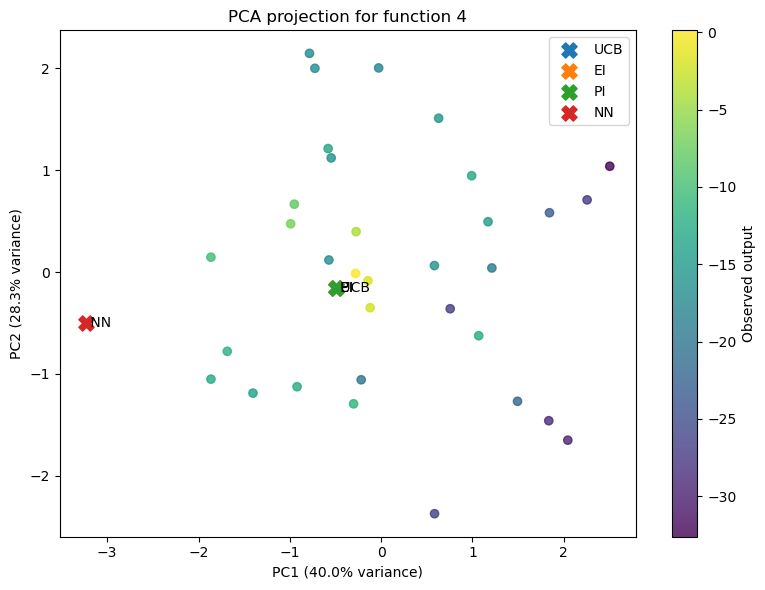

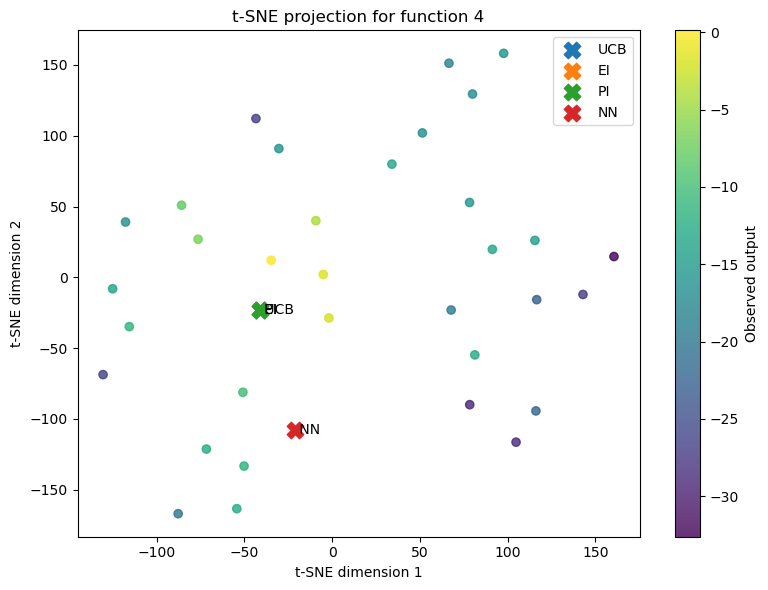

function number 5
Learned kernel: 1.51**2 * RBF(length_scale=0.794) + WhiteKernel(noise_level=0.00669)
Optimised log marginal likelihood: -10.94461003323429
Mean CV loss: 2578291.1500021117
reccomended_point_from_neual_net [0.00584932 0.00346685 0.98608702 0.99205309]
Next point UCB: [0.972452 0.98245  0.988402 0.997471]
Next point EI : [0.972452 0.98245  0.988402 0.997471]
Next point PI : [0.938944 0.995487 0.987628 0.993715]
Next point NN [0.00584932 0.00346685 0.98608702 0.99205309], mean validation loss 2578291.1500021117
previous input point [0.7066   0.999024 0.993655 0.986456]


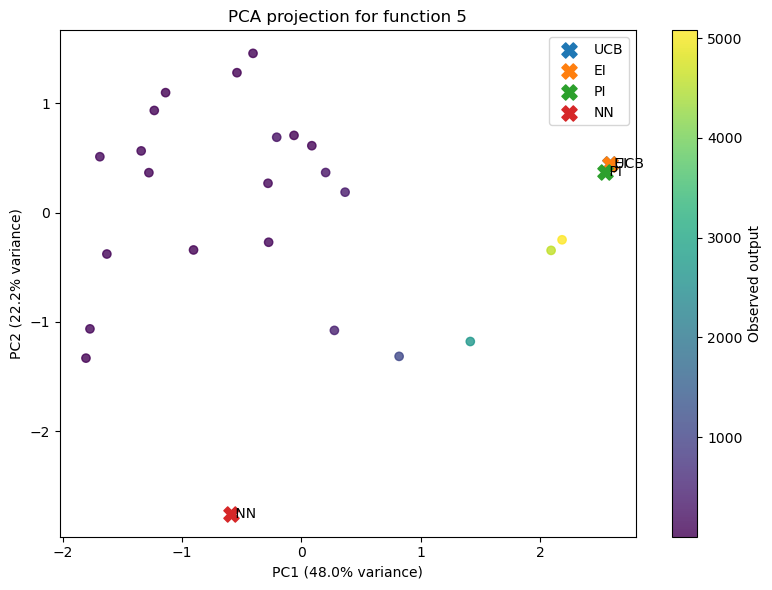

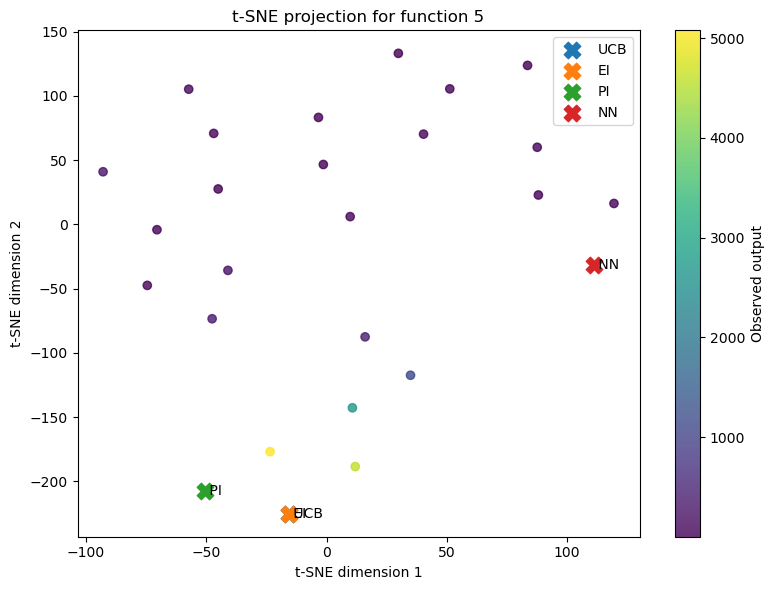

function number 6
Learned kernel: 1.07**2 * RBF(length_scale=0.531) + WhiteKernel(noise_level=6.13e-08)
Optimised log marginal likelihood: -23.91392511619483
Mean CV loss: 0.2664400688562542
reccomended_point_from_neual_net [0.02130233 0.22296333 0.05325067 0.89814837 0.00529708]
Next point UCB: [0.378975 0.275366 0.624127 0.828849 0.173408]
Next point EI : [0.405178 0.327205 0.547824 0.731492 0.151534]
Next point PI : [0.365077 0.260865 0.653363 0.855632 0.200885]
Next point NN [0.02130233 0.22296333 0.05325067 0.89814837 0.00529708], mean validation loss 0.2664400688562542
previous input point [0.495801 0.399488 0.429158 0.771171 0.19058 ]


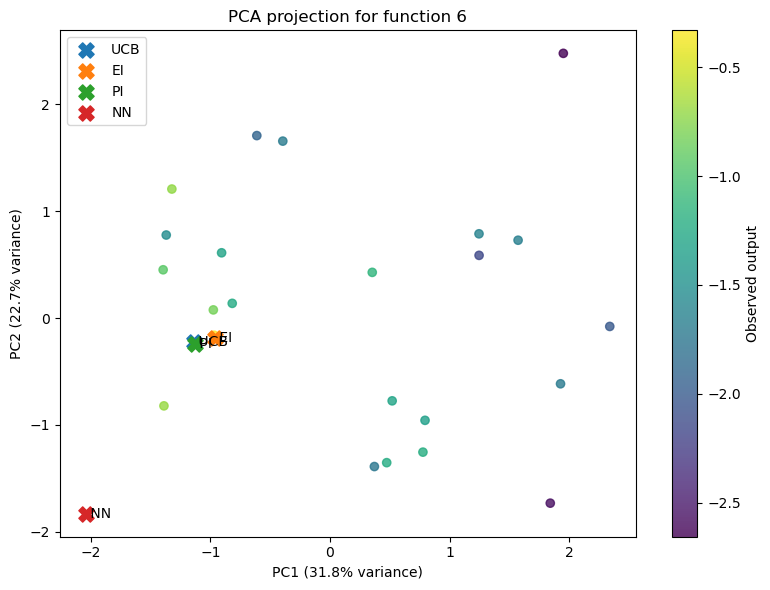

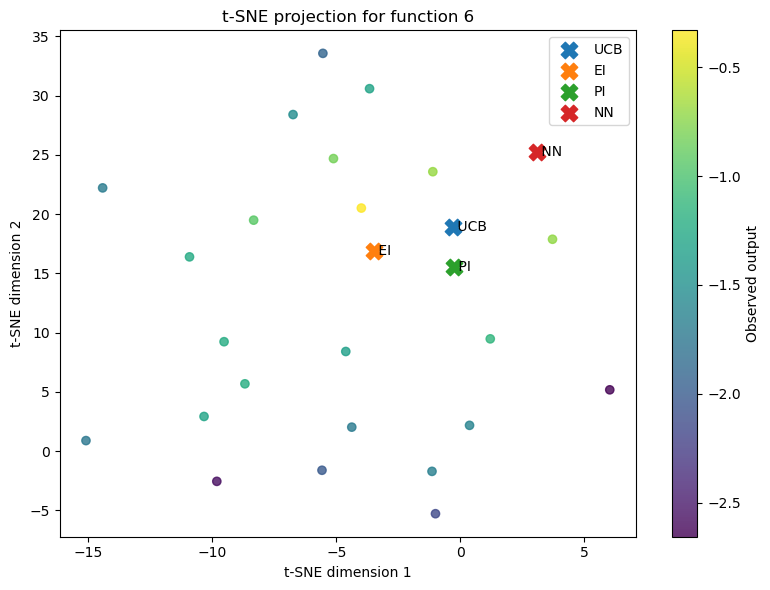

/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


function number 7
Learned kernel: 0.767**2 * RBF(length_scale=0.294) + WhiteKernel(noise_level=1e-08)
Optimised log marginal likelihood: -34.284338328939626
Mean CV loss: 0.1589157166900486
reccomended_point_from_neual_net [0.00528145 0.16603074 0.96527259 0.07721638 0.56940372 0.01766481]
Next point UCB: [0.067891 0.484071 0.229227 0.113272 0.319447 0.705017]
Next point EI : [0.067891 0.484071 0.229227 0.113272 0.319447 0.705017]
Next point PI : [0.088959 0.58502  0.203516 0.040799 0.380744 0.809708]
Next point NN [0.00528145 0.16603074 0.96527259 0.07721638 0.56940372 0.01766481], mean validation loss 0.1589157166900486
previous input point [0.061748 0.437126 0.232414 0.145199 0.362887 0.770468]


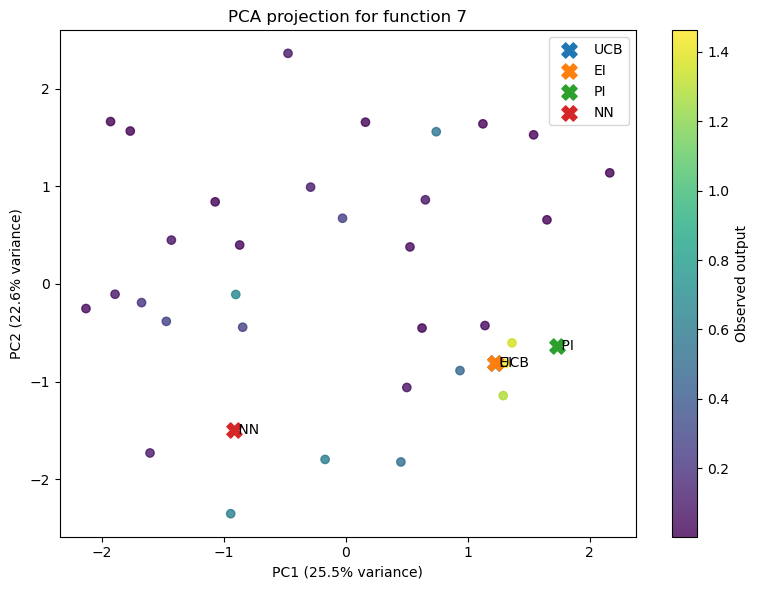

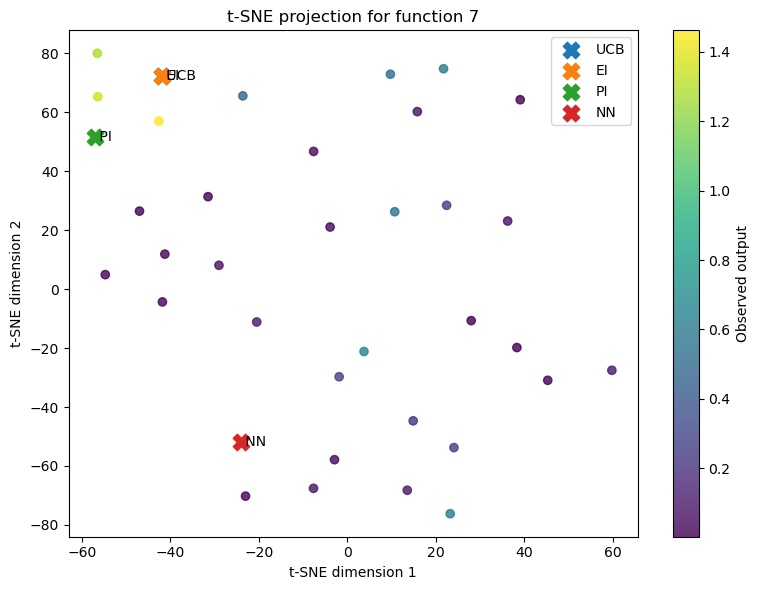

function number 8
Learned kernel: 2.39**2 * RBF(length_scale=1.51) + WhiteKernel(noise_level=0.000101)
Optimised log marginal likelihood: -26.58743286268132
Mean CV loss: 1.0034811391487717
reccomended_point_from_neual_net [0.01301707 0.03945886 0.06453084 0.04031943 0.93675655 0.62423289
 0.02640566 0.94594697]
Next point UCB: [0.119771 0.010084 0.17767  0.034046 0.9208   0.065449 0.097003 0.029167]
Next point EI : [0.119771 0.010084 0.17767  0.034046 0.9208   0.065449 0.097003 0.029167]
Next point PI : [0.087658 0.033985 0.154669 0.035129 0.830625 0.434857 0.247486 0.755192]
Next point NN [0.01301707 0.03945886 0.06453084 0.04031943 0.93675655 0.62423289
 0.02640566 0.94594697], mean validation loss 1.0034811391487717
previous input point [0.116894 0.299157 0.168593 0.255988 0.618273 0.617996 0.31299  0.44933 ]


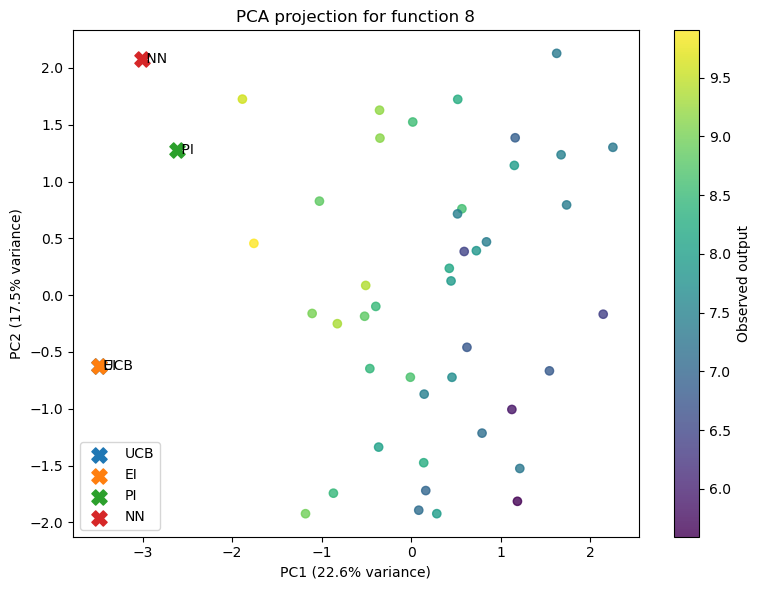

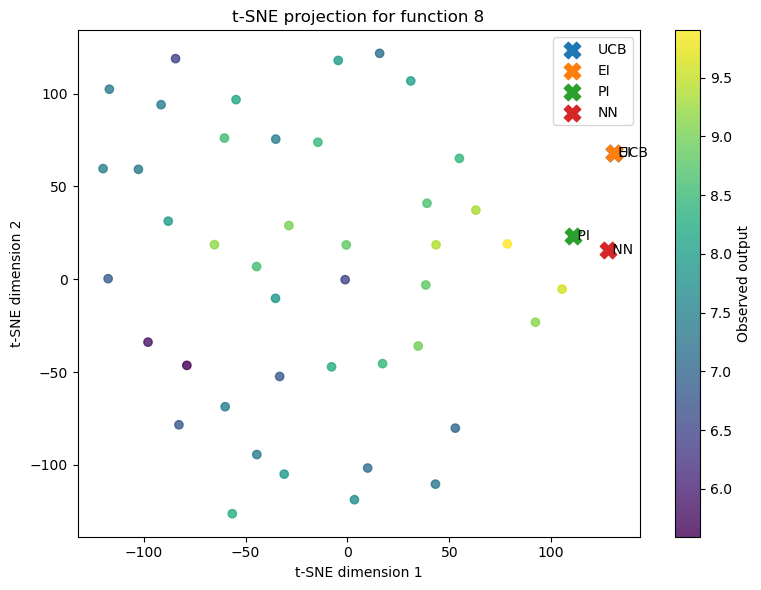

In [153]:
# optimisation loop

for k in range(1, 9):
    ins = np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_4/week_4_data/function_{k}/inputs.npy"
    )
    outs = np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_4/week_4_data/function_{k}/outputs.npy"
    )
   
    Beta = 1
    Xi = 0.2
    sample_size = int(1e6)
    in_cols = ins.shape[1]

    proposals = propose_points_from_learned_gp(
        ins=ins,
        outs=outs,
        sample_size=sample_size,
        in_cols=in_cols,
        Beta=Beta,
        Xi=Xi
    )

    model = proposals["model"]



    print(f"function number {k}")
    print("Learned kernel:", model.kernel_)
    print("Optimised log marginal likelihood:",
          model.log_marginal_likelihood(model.kernel_.theta))

    x_ucb = proposals["UCB"]
    x_ei = proposals["EI"]
    x_pi = proposals["PI"]

    #x_nn=simple_neural_network(ins,outs,sample_size, learn_rate=0.01)
    mean_val_loss,x_nn =simple_neural_net_w_5_cross_fold_validation(ins,outs,sample_size,learn_rate=0.001)


    print("Next point UCB:", x_ucb)
    print("Next point EI :", x_ei)
    print("Next point PI :", x_pi)
    print(f"Next point NN {x_nn}, mean validation loss {mean_val_loss}")
    print("previous input point", ins[-1])

    special_points = {
    "UCB": x_ucb,
    "EI": x_ei,
    "PI": x_pi,
    "NN": x_nn
}

    pca_results = conduct_PCA(
        observed_inputs=ins,
        special_points=special_points,
        standardise=True,
        n_components=2
    )

    plot_PCA_projection(
        pca_results,
        observed_outputs=outs,
        title=f"PCA projection for function {k}"
)
    
    tsne_results = conduct_tSNE(
        observed_inputs=ins,
        special_points=special_points,
        standardise=True,
        perplexity=10,
        max_iter=1000,
        random_state=42
    )

    plot_tSNE_projection(
        tsne_results,
        observed_outputs=outs,
        title=f"t-SNE projection for function {k}"
    )







        






Now going to implement a simple neural network as the surrogate model. 

In [141]:
import sys
from aima3 import learning
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as func
import sklearn 
from sklearn.model_selection import KFold




In [144]:
# start withfor k in range(1, 9):
k=1
for k in range(1,9):
    
    ins = np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_4/week_4_data/function_{k}/inputs.npy"
    )
    outs = np.load(
        f"/Users/luke_dev/Documents/ML_AI_imperial_course_codes/capstone_stage_2/week_4/week_4_data/function_{k}/outputs.npy"
    )



    # 1 hidden layer 

    print(ins.shape)

    in_cols=ins.shape[1]

    # create input tensor from ins of function 
    # X = torch.tensor(ins,dtype=torch.float32)#Use numpy commands – example input to Layer 2
    # y= torch.tensor(outs,dtype=torch.float32)
    # y=torch.reshape(y, (outs.shape[0],1))

    
    # K-fold cross validation 
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_val_losses=[]
    for train_idx, val_idx in kf.split(ins):
        X_train = torch.tensor(ins[train_idx], dtype=torch.float32)
        y_train = torch.tensor(outs[train_idx], dtype=torch.float32).view(-1, 1)

        X_val = torch.tensor(ins[val_idx], dtype=torch.float32)
        y_val = torch.tensor(outs[val_idx], dtype=torch.float32).view(-1, 1)


        model=nn.Sequential(
            nn.Linear(ins.shape[1],ins.shape[1]), # mapping 13x 2 inputs to 13x2 outputs 
            nn.ReLU(), # applying rectified linear unit activation function 
            nn.Linear(ins.shape[1],1) # mapping the 13x2 inputs to 13x1 outputs 
        )


        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # stochastic gradient descent 

        num_epochs=10000

        for epoch in range(num_epochs):
            # Forward pass: predictions from current model parameters
            y_pred = model(X_train)

            # Compute loss
            loss = criterion(y_pred, y_train)

            # Clear old gradients
            optimizer.zero_grad()

            # Backward pass: compute gradients of loss wrt parameters
            loss.backward()

            # Gradient descent step
            optimizer.step()
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val)
                val_loss = criterion(val_pred, y_val)

            # Print progress occasionally
            # if epoch % 2000 == 0:
            #     print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

            fold_val_losses.append(val_loss.item())



    mean_val_loss = np.mean(fold_val_losses)
    print("Mean CV loss:", mean_val_loss)

    post_mean,sample_ins=monte_carlo_sample_from_neural_net(sample_size,in_cols,model)
    # max post mean evaluation 
    max_post_mmean_idx=np.argmax(post_mean.detach().numpy())
    reccomended_point_from_neual_net=sample_ins[max_post_mmean_idx]
    print("reccomended_point_from_neual_net",reccomended_point_from_neual_net)






    



# so we would then use the trained network to predict a monte carlo sample of points in the domain, then use the accquisition functions to select the best next point 


(13, 2)
Mean CV loss: 0.0005321742196207063
reccomended_point_from_neual_net [2.55123851e-04 9.92588134e-01]
(13, 2)
Mean CV loss: 0.0727557817249489
reccomended_point_from_neual_net [0.99997255 0.99984253]
(18, 3)
Mean CV loss: 0.012365171037208056
reccomended_point_from_neual_net [0.00057189 0.01472882 0.00153078]
(33, 4)
Mean CV loss: 45.635350196018216
reccomended_point_from_neual_net [0.00357863 0.03020806 0.03567706 0.01598807]
(23, 4)
Mean CV loss: 2876466.5287470534
reccomended_point_from_neual_net [0.77395605 0.43887844 0.85859792 0.69736803]
(23, 5)
Mean CV loss: 0.21534099349904806
reccomended_point_from_neual_net [0.01905863 0.61616597 0.99659274 0.97483013 0.03163253]
(33, 6)
Mean CV loss: 0.11001071268375963
reccomended_point_from_neual_net [0.016494   0.07870891 0.83235796 0.04528172 0.04735378 0.99914452]
(43, 8)
Mean CV loss: 0.23650405495524407
reccomended_point_from_neual_net [0.01301707 0.03945886 0.06453084 0.04031943 0.93675655 0.62423289
 0.02640566 0.94594697]


In [139]:
print(outs.shape)
print(ins.shape)

(43,)
(43, 8)
